#Objectif Stratégique d'Automatidata

L'objectif de cette mission est de permettre à Automatidata de remplir son rôle de conseiller stratégique auprès de la New York City Taxi and Limousine Commission (TLC) en convertissant leurs données massives (plus de 200 000 licences et 1 million de trajets quotidiens) en un outil prédictif de haute précision.

##Les composantes de cet objectif :

Transformation de données stockées : Automatidata doit extraire de la valeur des "données inutilisées" de la TLC pour créer un modèle de régression linéaire multiple capable d'estimer les tarifs des taxis avant la course.

##Aide à la décision et Transparence :
 En développant cet outil, Automatidata fournit une "perspective commerciale stratégique" qui permet à la TLC de mieux réguler les tarifs et d'offrir une meilleure expérience client grâce à la prévisibilité des coûts.

Validation et Fiabilité : La mission d'Automatidata inclut la vérification rigoureuse des hypothèses statistiques du modèle pour garantir que les conclusions présentées aux parties prenantes de la TLC sont robustes et exploitables en situation réelle.

#Construire un modèle de régression linéaire multiple

#**PACE: PLAN**

##Tâche 1. Importations et chargement

Importez les packages dont vous avez appris qu'ils sont nécessaires à la construction de modèles de régression linéaire.

In [ ]:
# Imports
# Packages for numerics + dataframes
import pandas as pd
import numpy as np

# Packages for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Packages for date conversions for calculating trip durations
from datetime import datetime
from datetime import date
from datetime import timedelta

# Packages for OLS, MLR, confusion matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import sklearn.metrics as metrics # For confusion matrix
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error

In [ ]:
df0=pd.read_csv("/content/drive/MyDrive/PYTHON/coursera/porfolio/2017_Yellow_Taxi_Trip_Data.csv")

In [ ]:
df0.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80


#Tâche 2a. Explorer les données avec l'analyse exploratoire des données (EDA)

Analyser et découvrir des données, en recherchant des corrélations, des données manquantes, des valeurs aberrantes et des doublons.

In [ ]:
# Start with `.shape` and `.info()`

# Keep `df0` as the original dataframe and create a copy (df) where changes will go
# Can revert `df` to `df0` if needed down the line
df = df0.copy()

# Display the dataset's shape
print(df.shape)

# Display basic info about the dataset
df.info()

(22699, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             22699 non-null  int64  
 1   VendorID               22699 non-null  int64  
 2   tpep_pickup_datetime   22699 non-null  object 
 3   tpep_dropoff_datetime  22699 non-null  object 
 4   passenger_count        22699 non-null  int64  
 5   trip_distance          22699 non-null  float64
 6   RatecodeID             22699 non-null  int64  
 7   store_and_fwd_flag     22699 non-null  object 
 8   PULocationID           22699 non-null  int64  
 9   DOLocationID           22699 non-null  int64  
 10  payment_type           22699 non-null  int64  
 11  fare_amount            22699 non-null  float64
 12  extra                  22699 non-null  float64
 13  mta_tax                22699 non-null  float64
 14  tip_amount             22699 non-null  flo

Vérifiez les données manquantes et les doublons à l'aide de .isna()et .drop_duplicates().

In [ ]:
# Check for missing data and duplicates using .isna() and .drop_duplicates()
### YOUR CODE HERE ###

# Check for duplicates
print('Shape of dataframe:', df.shape)
print('Shape of dataframe with duplicates dropped:', df.drop_duplicates().shape)

# Check for missing values in dataframe
print('Total count of missing values:', df.isna().sum().sum())

# Display missing values per column in dataframe
print('Missing values per column:')
df.isna().sum()

Shape of dataframe: (22699, 18)
Shape of dataframe with duplicates dropped: (22699, 18)
Total count of missing values: 0
Missing values per column:


,0
Unnamed: 0,0
VendorID,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,0
trip_distance,0
RatecodeID,0
store_and_fwd_flag,0
PULocationID,0
DOLocationID,0


Les données ne contiennent ni doublons ni valeurs manquantes.

In [ ]:
# Display descriptive stats about the data
df.describe()

,Unnamed: 0,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,2.269900e+04,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000
mean,5.675849e+07,1.556236,1.642319,2.913313,1.043394,162.412353,161.527997,1.336887,13.026629,0.333275,0.497445,1.835781,0.312542,0.299551,16.310502
std,3.274493e+07,0.496838,1.285231,3.653171,0.708391,66.633373,70.139691,0.496211,13.243791,0.463097,0.039465,2.800626,1.399212,0.015673,16.097295
min,1.212700e+04,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,-120.000000,-1.000000,-0.500000,0.000000,0.000000,-0.300000,-120.300000
25%,2.852056e+07,1.000000,1.000000,0.990000,1.000000,114.000000,112.000000,1.000000,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,8.750000
50%,5.673150e+07,2.000000,1.000000,1.610000,1.000000,162.000000,162.000000,1.000000,9.500000,0.000000,0.500000,1.350000,0.000000,0.300000,11.800000
75%,8.537452e+07,2.000000,2.000000,3.060000,1.000000,233.000000,233.000000,2.000000,14.500000,0.500000,0.500000,2.450000,0.000000,0.300000,17.800000
max,1.134863e+08,2.000000,6.000000,33.960000,99.000000,265.000000,265.000000,4.000000,999.990000,4.500000,0.500000,200.000000,19.100000,0.300000,1200.290000


Ce tableau de statistiques descriptives révèle certains éléments importants. Par exemple, on observe clairement des valeurs aberrantes pour plusieurs variables, comme tip_amount(200 $) et total_amount(1 200 $). De plus, certaines variables, telles que mta_tax, semblent presque constantes dans l’ensemble des données, ce qui suggère qu’elles ne seraient pas très prédictives.

##Tâche 2b. Convertir les colonnes de prise en charge et de dépôt au format date/heure.

In [ ]:
# Check the format of the data
df['tpep_dropoff_datetime'][0]

'03/25/2017 9:09:47 AM'

In [ ]:
# Convert datetime columns to datetime
# Display data types of `tpep_pickup_datetime`, `tpep_dropoff_datetime`
print('Data type of tpep_pickup_datetime:', df['tpep_pickup_datetime'].dtype)
print('Data type of tpep_dropoff_datetime:', df['tpep_dropoff_datetime'].dtype)

# Convert `tpep_pickup_datetime` to datetime format
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'], format='%m/%d/%Y %I:%M:%S %p')

# Convert `tpep_dropoff_datetime` to datetime format
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'], format='%m/%d/%Y %I:%M:%S %p')

# Display data types of `tpep_pickup_datetime`, `tpep_dropoff_datetime`
print('Data type of tpep_pickup_datetime:', df['tpep_pickup_datetime'].dtype)
print('Data type of tpep_dropoff_datetime:', df['tpep_dropoff_datetime'].dtype)

df.head(3)

Data type of tpep_pickup_datetime: object
Data type of tpep_dropoff_datetime: object
Data type of tpep_pickup_datetime: datetime64[ns]
Data type of tpep_dropoff_datetime: datetime64[ns]


,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56
1,35634249,1,2017-04-11 14:53:28,2017-04-11 15:19:58,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80
2,106203690,1,2017-12-15 07:26:56,2017-12-15 07:34:08,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75


##Tâche 2c. Créer une colonne de durée

Créez une nouvelle colonne duration qui représente le nombre total de minutes que chaque trajet en taxi a duré.

In [ ]:
# Create `duration` column
df['duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime'])/np.timedelta64(1,'m')

##Valeurs aberrantes

Appel df.info()à examiner les colonnes et à décider lesquelles vérifier pour détecter les valeurs aberrantes.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Unnamed: 0             22699 non-null  int64         
 1   VendorID               22699 non-null  int64         
 2   tpep_pickup_datetime   22699 non-null  datetime64[ns]
 3   tpep_dropoff_datetime  22699 non-null  datetime64[ns]
 4   passenger_count        22699 non-null  int64         
 5   trip_distance          22699 non-null  float64       
 6   RatecodeID             22699 non-null  int64         
 7   store_and_fwd_flag     22699 non-null  object        
 8   PULocationID           22699 non-null  int64         
 9   DOLocationID           22699 non-null  int64         
 10  payment_type           22699 non-null  int64         
 11  fare_amount            22699 non-null  float64       
 12  extra                  22699 non-null  float64       
 13  m

Sachant que de nombreuses caractéristiques ne seront pas utilisées pour ajuster votre modèle, les colonnes les plus importantes à vérifier pour détecter les valeurs aberrantes sont probablement les suivantes :

trip_distance
fare_amount
duration

##Tâche 2d. Diagrammes en boîte

Tracez un diagramme en boîte pour chaque caractéristique : trip_distance, fare_amount, duration.

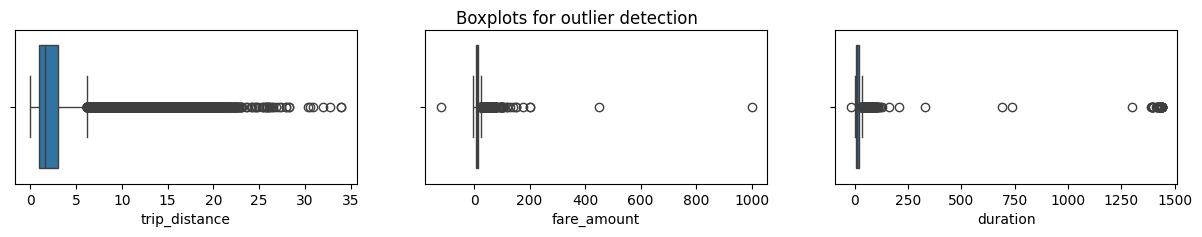

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 2))
fig.suptitle('Boxplots for outlier detection')
sns.boxplot(ax=axes[0], x=df['trip_distance'])
sns.boxplot(ax=axes[1], x=df['fare_amount'])
sns.boxplot(ax=axes[2], x=df['duration'])
plt.show();

Les trois variables présentent toutes des valeurs aberrantes. Certaines sont extrêmes, d'autres beaucoup moins.

La distance à vol d'oiseau entre l'extrémité sud de Staten Island et l'extrémité nord de Manhattan est de 48 kilomètres (30 miles). Compte tenu de cette information et de la distribution des valeurs dans cette colonne, il est raisonnable de ne pas les modifier. Cependant, les valeurs de fare_amountet durationsemblent présenter des valeurs aberrantes problématiques, notamment à leurs valeurs élevées.

Probablement pas pour les deux derniers, mais pour le trip_distancereste, ça pourrait aller.

##Task 2e. Imputations

trip_distancevaleurs aberrantes
Les statistiques récapitulatives indiquent que certaines distances de trajet sont nulles. Ces valeurs reflètent-elles des données erronées ou s'agit-il de trajets très courts arrondis à l'inférieur ?

Pour vérifier, triez les valeurs de la colonne, supprimez les doublons et examinez les 10 valeurs les plus faibles. S'agit-il de valeurs arrondies ou de valeurs exactes ?

In [ ]:
# Are trip distances of 0 bad data or very short trips rounded down?
sorted(set(df['trip_distance']))[:10]

[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09]

Les distances sont enregistrées avec une grande précision. Cependant, il est possible que certaines distances soient nulles si un passager a commandé un taxi puis s'est ravisé. Par ailleurs, y a-t-il suffisamment de valeurs nulles dans les données pour que cela pose problème ?

Calculer le nombre de trajets où la valeur trip_distanceest zéro.

In [ ]:
sum(df['trip_distance']==0)

148

 148 trajets sur environ 23 000 représentent un nombre relativement insignifiant. On pourrait lui attribuer une valeur de 0,01, mais cela n’aurait probablement qu’un impact négligeable sur le modèle. Par conséquent, cette trip_distancecolonne restera inchangée en ce qui concerne les valeurs aberrantes.

fare_amountvaleurs aberrantes

In [ ]:
df['fare_amount'].describe()

,fare_amount
count,22699.000000
mean,13.026629
std,13.243791
min,-120.000000
25%,6.500000
50%,9.500000
75%,14.500000
max,999.990000


L'éventail des valeurs dans la fare_amountcolonne est large et les valeurs extrêmes n'ont pas beaucoup de sens.

Valeurs faibles : Les valeurs négatives posent problème. La valeur zéro pourrait être légitime si le taxi avait enregistré une course immédiatement annulée.

Valeurs élevées : Le montant maximal du tarif dans cet ensemble de données est proche de 1 000 $, ce qui semble très improbable. Il est possible de plafonner les valeurs élevées de cette variable en se basant sur l’intuition et les statistiques. L’écart interquartile (EIQ) est de 8 $. La formule standard Q3 + (1.5 * IQR)donne 26,50 $. Ce résultat ne semble pas approprié pour le plafond du tarif maximal. Dans ce cas, nous utiliserons un facteur de 1 6, ce qui donne un plafond de 62,50 $.

Imputer les valeurs inférieures à 0 $ avec 0.

In [ ]:
# Impute values less than $0 with 0
df.loc[df['fare_amount'] < 0, 'fare_amount'] = 0
df['fare_amount'].min()

0.0

In [ ]:
def outlier_imputer(column_list, iqr_factor):
    '''
    Impute upper-limit values in specified columns based on their interquartile range.

    Arguments:
        column_list: A list of columns to iterate over
        iqr_factor: A number representing x in the formula:
                    Q3 + (x * IQR). Used to determine maximum threshold,
                    beyond which a point is considered an outlier.

    The IQR is computed for each column in column_list and values exceeding
    the upper threshold for each column are imputed with the upper threshold value.
    '''
    for col in column_list:
        # Reassign minimum to zero
        df.loc[df[col] < 0, col] = 0

        # Calculate upper threshold
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        upper_threshold = q3 + (iqr_factor * iqr)
        print(col)
        print('q3:', q3)
        print('upper_threshold:', upper_threshold)

        # Reassign values > threshold to threshold
        df.loc[df[col] > upper_threshold, col] = upper_threshold
        print(df[col].describe())
        print()

In [ ]:
outlier_imputer(['fare_amount'], 6)

fare_amount
q3: 14.5
upper_threshold: 62.5
count    22699.000000
mean        12.897913
std         10.541137
min          0.000000
25%          6.500000
50%          9.500000
75%         14.500000
max         62.500000
Name: fare_amount, dtype: float64



duration outliers

In [ ]:
df['duration'].describe()

duration colonne présente des valeurs problématiques à ses extrémités inférieure et supérieure.

Valeurs faibles : aucune valeur ne doit représenter une durée négative. Imputer toutes les durées négatives avec un point 0.

Valeurs élevées : imputez les valeurs élevées de la même manière que vous avez imputé les valeurs aberrantes élevées pour les tarifs : Q3 + (6 * IQR).

In [ ]:
# Impute a 0 for any negative values
df.loc[df['duration'] < 0, 'duration'] = 0
df['duration'].min()

0.0

In [ ]:
# Impute the high outliers
outlier_imputer(['duration'], 6)

duration
q3: 18.383333333333333
upper_threshold: 88.78333333333333
count    22699.000000
mean        14.460555
std         11.947043
min          0.000000
25%          6.650000
50%         11.183333
75%         18.383333
max         88.783333
Name: duration, dtype: float64



##Task 3a. Feature engineering

#### Create `mean_distance` column

When deployed, the model will not know the duration of a trip until after the trip occurs, so you cannot train a model that uses this feature. However, you can use the statistics of trips you *do* know to generalize about ones you do not know.

In this step, create a column called `mean_distance` that captures the mean distance for each group of trips that share pickup and dropoff points.

For example, if your data were:

|Trip|Start|End|Distance|
|--: |:---:|:-:|    |
| 1  | A   | B | 1  |
| 2  | C   | D | 2  |
| 3  | A   | B |1.5 |
| 4  | D   | C | 3  |

The results should be:
```
A -> B: 1.25 miles
C -> D: 2 miles
D -> C: 3 miles
```

Notice that C -> D is not the same as D -> C. All trips that share a unique pair of start and end points get grouped and averaged.

Then, a new column `mean_distance` will be added where the value at each row is the average for all trips with those pickup and dropoff locations:

|Trip|Start|End|Distance|mean_distance|
|--: |:---:|:-:|  :--   |:--   |
| 1  | A   | B | 1      | 1.25 |
| 2  | C   | D | 2      | 2    |
| 3  | A   | B |1.5     | 1.25 |
| 4  | D   | C | 3      | 3    |


Begin by creating a helper column called `pickup_dropoff`, which contains the unique combination of pickup and dropoff location IDs for each row.

One way to do this is to convert the pickup and dropoff location IDs to strings and join them, separated by a space. The space is to ensure that, for example, a trip with pickup/dropoff points of 12 & 151 gets encoded differently than a trip with points 121 & 51.

So, the new column would look like this:

|Trip|Start|End|pickup_dropoff|
|--: |:---:|:-:|  :--         |
| 1  | A   | B | 'A B'        |
| 2  | C   | D | 'C D'        |
| 3  | A   | B | 'A B'        |
| 4  | D   | C | 'D C'        |


In [ ]:
# Create `pickup_dropoff` column
df['pickup_dropoff'] = df['PULocationID'].astype(str) + ' ' + df['DOLocationID'].astype(str)
df['pickup_dropoff'].head(2)

,pickup_dropoff
0,100 231
1,186 43


Utilisez maintenant une groupby()instruction pour regrouper chaque ligne selon la nouvelle pickup_dropoffcolonne, calculer la moyenne et ne conserver que les valeurs de cette trip_distancecolonne. Affectez les résultats à une variable nommée grouped.

In [ ]:
grouped = df.groupby('pickup_dropoff').mean(numeric_only=True)[['trip_distance']]
grouped[:5]

,trip_distance
pickup_dropoff,
1 1,2.433333
10 148,15.700000
100 1,16.890000
100 100,0.253333
100 107,1.180000


grouped est un objet de la DataFrameclasse.

Convertissez-le en dictionnaire à l'aide de la to_dict()méthode appropriée. Affectez le résultat à une variable grouped_dict. Nous obtiendrons ainsi un dictionnaire dont trip_distanceles clés sont des dictionnaires internes. Les clés de ce dictionnaire correspondent aux points de prise en charge et de dépose, et ses valeurs aux distances moyennes. Ce sont les informations recherchées.

groupby est un objet de la classe DataFrame.

Convertissez-le en dictionnaire en utilisant la méthode to_dict()
. Assignez le résultat à une variable appelée grouped_dict. Cela produira un dictionnaire avec une clé trip_distance dont les valeurs sont un autre dictionnaire. Les clés du dictionnaire interne sont les points de prise en charge/dépose et ses valeurs sont les distances moyennes. C’est l’information dont vous avez besoin.

Exemple :
grouped_dict = {'trip_distance': {'A B': 1.25, 'C D': 2, 'D C': 3}}

Réassignez le dictionnaire grouped_dict afin qu’il ne contienne que le dictionnaire interne. Autrement dit, supprimez trip_distance comme clé, de sorte que :

Exemple :
grouped_dict = {'A B': 1.25, 'C D': 2, 'D C': 3}

In [ ]:
# 1. Convert `grouped` to a dictionary
grouped_dict = grouped.to_dict()

# 2. Reassign to only contain the inner dictionary
grouped_dict = grouped_dict['trip_distance']

Créez une colonne mean_distance qui est une copie de la colonne auxiliaire pickup_dropoff.

Utilisez la méthode map() sur la série mean_distance. Passez grouped_dict comme argument. Réassignez le résultat à la série mean_distance.

Lorsque vous passez un dictionnaire à la méthode Series.map(), elle remplace les données de la série lorsque celles-ci correspondent aux clés du dictionnaire. Les valeurs imputées sont les valeurs associées dans le dictionnaire.

Exemple :

df['mean_distance']

mean_distance
'A B'
'C D'
'A B'
'D C'
'E F'

grouped_dict = {'A B': 1.25, 'C D': 2, 'D C': 3}

df['mean_distance'] = df['mean_distance'].map(grouped_dict)

df['mean_distance']

mean_distance
1.25
2
1.25

In [ ]:
# 1. Create a mean_distance column that is a copy of the pickup_dropoff helper column
df['mean_distance'] = df['pickup_dropoff']

# 2. Map `grouped_dict` to the `mean_distance` column
df['mean_distance'] = df['mean_distance'].map(grouped_dict)

# Confirm that it worked
df[(df['PULocationID']==100) & (df['DOLocationID']==231)][['mean_distance']]

,mean_distance
0,3.521667
4909,3.521667
16636,3.521667
18134,3.521667
19761,3.521667
20581,3.521667


##Créez une colonne mean_duration.

Répétez le processus utilisé pour créer la colonne mean_distance afin de créer une colonne mean_duration.

In [ ]:
grouped = df.groupby('pickup_dropoff').mean(numeric_only=True)[['duration']]
grouped

# Create a dictionary where keys are unique pickup_dropoffs and values are
# mean trip duration for all trips with those pickup_dropoff combos
grouped_dict = grouped.to_dict()
grouped_dict = grouped_dict['duration']

df['mean_duration'] = df['pickup_dropoff']
df['mean_duration'] = df['mean_duration'].map(grouped_dict)

# Confirm that it worked
df[(df['PULocationID']==100) & (df['DOLocationID']==231)][['mean_duration']]

,mean_duration
0,22.847222
4909,22.847222
16636,22.847222
18134,22.847222
19761,22.847222
20581,22.847222


##Créez les colonnes day et month.

Créez deux nouvelles colonnes, day (nom du jour) et month (nom du mois) en extrayant les informations pertinentes de la colonne tpep_pickup_datetime.

In [ ]:
# Create 'day' col
df['day'] = df['tpep_pickup_datetime'].dt.day_name().str.lower()

# Create 'month' col
df['month'] = df['tpep_pickup_datetime'].dt.strftime('%b').str.lower()

Créez la colonne rush_hour.

Définissez les heures de pointe comme :

N’importe quel jour de semaine (pas samedi ni dimanche) ET

Soit entre 06:00–10:00, soit entre 16:00–20:00

Créez une colonne binaire rush_hour qui contient 1 si le trajet a eu lieu pendant les heures de pointe et 0 sinon.

In [ ]:
# Create 'rush_hour' col
df['rush_hour'] = df['tpep_pickup_datetime'].dt.hour

# If day is Saturday or Sunday, impute 0 in `rush_hour` column
df.loc[df['day'].isin(['saturday', 'sunday']), 'rush_hour'] = 0

In [ ]:
def rush_hourizer(hour):
    if 6 <= hour['rush_hour'] < 10:
        val = 1
    elif 16 <= hour['rush_hour'] < 20:
        val = 1
    else:
        val = 0
    return val

In [ ]:
# Apply the `rush_hourizer()` function to the new column
df.loc[(df.day != 'saturday') & (df.day != 'sunday'), 'rush_hour'] = df.apply(rush_hourizer, axis=1)
df.head()

/tmp/ipykernel_614/3278249955.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0 1 1 ... 1 0 0]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  df.loc[(df.day != 'saturday') & (df.day != 'sunday'), 'rush_hour'] = df.apply(rush_hourizer, axis=1)


,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,...,tolls_amount,improvement_surcharge,total_amount,duration,pickup_dropoff,mean_distance,mean_duration,day,month,rush_hour
0,24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,N,100,231,...,0.0,0.3,16.56,14.066667,100 231,3.521667,22.847222,saturday,mar,0
1,35634249,1,2017-04-11 14:53:28,2017-04-11 15:19:58,1,1.80,1,N,186,43,...,0.0,0.3,20.80,26.500000,186 43,3.108889,24.470370,tuesday,apr,0
2,106203690,1,2017-12-15 07:26:56,2017-12-15 07:34:08,1,1.00,1,N,262,236,...,0.0,0.3,8.75,7.200000,262 236,0.881429,7.250000,friday,dec,1
3,38942136,2,2017-05-07 13:17:59,2017-05-07 13:48:14,1,3.70,1,N,188,97,...,0.0,0.3,27.69,30.250000,188 97,3.700000,30.250000,sunday,may,0
4,30841670,2,2017-04-15 23:32:20,2017-04-15 23:49:03,1,4.37,1,N,4,112,...,0.0,0.3,17.80,16.716667,4 112,4.435000,14.616667,saturday,apr,0


##Task 4. Scatter plot
Create a scatterplot to visualize the relationship between mean_duration and fare_amount.

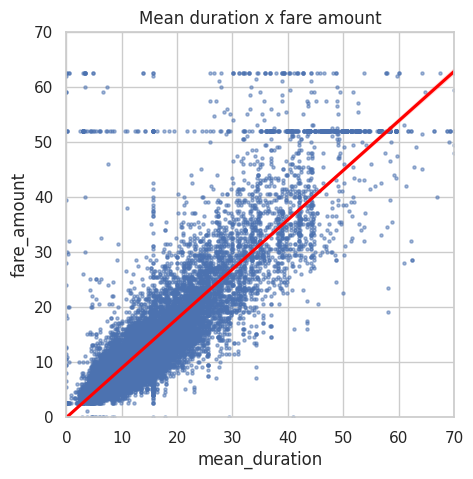

In [ ]:
# Create a scatter plot of duration and trip_distance, with a line of best fit
sns.set(style='whitegrid')
f = plt.figure()
f.set_figwidth(5)
f.set_figheight(5)
sns.regplot(x=df['mean_duration'], y=df['fare_amount'],
            scatter_kws={'alpha':0.5, 's':5},
            line_kws={'color':'red'})
plt.ylim(0, 70)
plt.xlim(0, 70)
plt.title('Mean duration x fare amount')
plt.show()

La variable mean_duration est corrélée avec la variable cible. Mais que représentent les lignes horizontales autour des montants de 52 dollars et 63 dollars ? Quelles sont ces valeurs et combien y en a-t-il ?

Vous savez déjà ce que représente l’une de ces lignes. 62,50 dollars est la valeur maximale imputée pour les valeurs aberrantes (outliers), donc tous les anciens outliers ont maintenant un montant de course de 62,50 $. Quelle est l’autre ligne ?

Vérifiez la valeur des trajets dans la deuxième ligne horizontale du graphique de dispersion (scatter plot)

In [ ]:
df[df['fare_amount'] > 50]['fare_amount'].value_counts().head()

,count
fare_amount,
52.0,514
62.5,84
59.0,9
50.5,9
57.5,8


Note d’exemple : Il y a 514 trajets dont le tarif est de 52 $.

Examinez les 30 premiers de ces trajets.

In [ ]:
# Set pandas to display all columns
pd.set_option('display.max_columns', None)
df[df['fare_amount']==52].head(30)

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration,pickup_dropoff,mean_distance,mean_duration,day,month,rush_hour
11,18600059,2,2017-03-05 19:15:30,2017-03-05 19:52:18,2,18.90,2,N,236,132,1,52.0,0.0,0.5,14.58,5.54,0.3,72.92,36.800000,236 132,19.211667,40.500000,sunday,mar,0
110,47959795,1,2017-06-03 14:24:57,2017-06-03 15:31:48,1,18.00,2,N,132,163,1,52.0,0.0,0.5,0.00,0.00,0.3,52.80,66.850000,132 163,19.229000,52.941667,saturday,jun,0
161,95729204,2,2017-11-11 20:16:16,2017-11-11 20:17:14,1,0.23,2,N,132,132,2,52.0,0.0,0.5,0.00,0.00,0.3,52.80,0.966667,132 132,2.255862,3.021839,saturday,nov,0
247,103404868,2,2017-12-06 23:37:08,2017-12-07 00:06:19,1,18.93,2,N,132,79,2,52.0,0.0,0.5,0.00,0.00,0.3,52.80,29.183333,132 79,19.431667,47.275000,wednesday,dec,0
379,80479432,2,2017-09-24 23:45:45,2017-09-25 00:15:14,1,17.99,2,N,132,234,1,52.0,0.0,0.5,14.64,5.76,0.3,73.20,29.483333,132 234,17.654000,49.833333,sunday,sep,0
388,16226157,1,2017-02-28 18:30:05,2017-02-28 19:09:55,1,18.40,2,N,132,48,2,52.0,4.5,0.5,0.00,5.54,0.3,62.84,39.833333,132 48,18.761905,58.246032,tuesday,feb,1
406,55253442,2,2017-06-05 12:51:58,2017-06-05 13:07:35,1,4.73,2,N,228,88,2,52.0,0.0,0.5,0.00,5.76,0.3,58.56,15.616667,228 88,4.730000,15.616667,monday,jun,0
449,65900029,2,2017-08-03 22:47:14,2017-08-03 23:32:41,2,18.21,2,N,132,48,2,52.0,0.0,0.5,0.00,5.76,0.3,58.56,45.450000,132 48,18.761905,58.246032,thursday,aug,0
468,80904240,2,2017-09-26 13:48:26,2017-09-26 14:31:17,1,17.27,2,N,186,132,2,52.0,0.0,0.5,0.00,5.76,0.3,58.56,42.850000,186 132,17.096000,42.920000,tuesday,sep,0
520,33706214,2,2017-04-23 21:34:48,2017-04-23 22:46:23,6,18.34,2,N,132,148,1,52.0,0.0,0.5,5.00,0.00,0.3,57.80,71.583333,132 148,17.994286,46.340476,sunday,apr,0


Il semble que presque tous les trajets dans les 30 premières lignes où le tarif est de 52 $ commencent ou se terminent à l’emplacement 132, et tous ont un RatecodeID égal à 2.

Il n’y a pas de raison immédiatement évidente expliquant pourquoi PULocation 132 aurait autant de trajets avec un tarif de 52 dollars. Ils se produisent à différents jours, à différentes heures, avec les deux fournisseurs, et dans tous les mois. Cependant, on observe de nombreux montants de péage de 5,76 $ et 5,54 $. Cela semble indiquer que l’emplacement 132 se situe dans une zone qui nécessite fréquemment des péages pour y accéder ou en partir. Il est donc probable qu’il s’agisse d’un aéroport.

Le dictionnaire de données indique que RatecodeID = 2 correspond aux trajets vers John F. Kennedy International Airport. Une recherche rapide sur Google pour « new york city taxi flat rate $52 » montre qu’en 2017 (année de collecte de ces données), il existait effectivement un tarif forfaitaire de taxi entre l’aéroport JFK (dans le Queens) et Manhattan.

Comme RatecodeID est connu grâce au dictionnaire de données, les valeurs associées à ce code tarifaire peuvent être réimputées dans les données après que le modèle ait effectué ses prédictions. De cette manière, vous savez que ces points de données seront toujours corrects.

##Tâche 5 : Isoler les variables de modélisation

Supprimez les variables qui sont redondantes, non pertinentes ou qui ne seront pas disponibles dans un environnement de production (déployé).

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Unnamed: 0             22699 non-null  int64         
 1   VendorID               22699 non-null  int64         
 2   tpep_pickup_datetime   22699 non-null  datetime64[ns]
 3   tpep_dropoff_datetime  22699 non-null  datetime64[ns]
 4   passenger_count        22699 non-null  int64         
 5   trip_distance          22699 non-null  float64       
 6   RatecodeID             22699 non-null  int64         
 7   store_and_fwd_flag     22699 non-null  object        
 8   PULocationID           22699 non-null  int64         
 9   DOLocationID           22699 non-null  int64         
 10  payment_type           22699 non-null  int64         
 11  fare_amount            22699 non-null  float64       
 12  extra                  22699 non-null  float64       
 13  m

In [ ]:
df2 = df.copy()

df2 = df2.drop(['Unnamed: 0', 'tpep_dropoff_datetime', 'tpep_pickup_datetime',
               'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID',
               'payment_type', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
               'total_amount', 'tpep_dropoff_datetime', 'tpep_pickup_datetime', 'duration',
               'pickup_dropoff', 'day', 'month'
               ], axis=1)

df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   VendorID         22699 non-null  int64  
 1   passenger_count  22699 non-null  int64  
 2   fare_amount      22699 non-null  float64
 3   mean_distance    22699 non-null  float64
 4   mean_duration    22699 non-null  float64
 5   rush_hour        22699 non-null  int64  
dtypes: float64(3), int64(3)
memory usage: 1.0 MB


Tâche 6 : Pair plot

Créez un pairplot pour visualiser les relations par paires entre fare_amount, mean_duration et mean_distance.

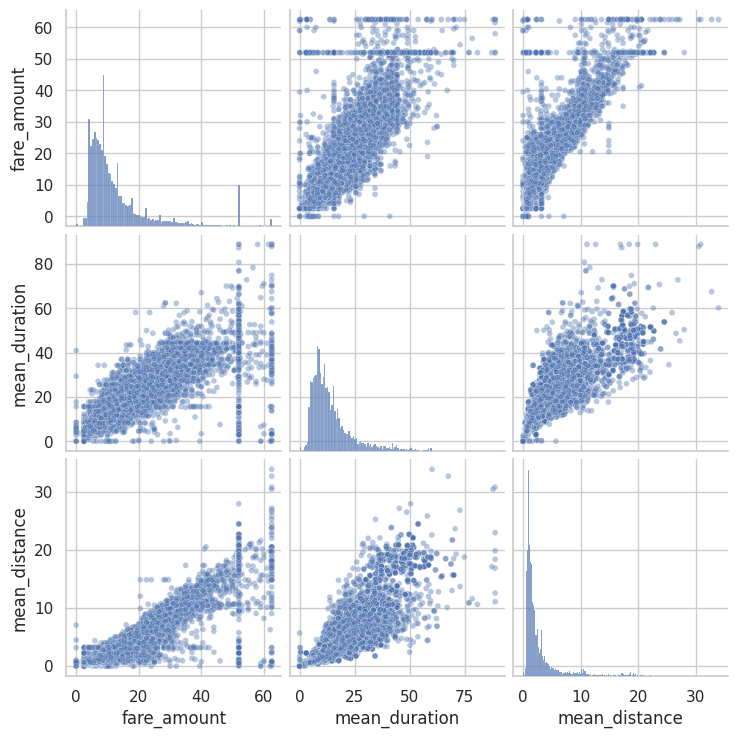

In [ ]:
# Create a pairplot to visualize pairwise relationships between variables in the data
### YOUR CODE HERE ###

sns.pairplot(df2[['fare_amount', 'mean_duration', 'mean_distance']],
             plot_kws={'alpha':0.4, 'size':5},
             );

Ces variables montrent toutes une corrélation linéaire entre elles. Il faut examiner cela plus en détail.

##Task 7. Identify correlations

Voici comment créer une matrice de corrélation pour identifier les variables les plus corrélées :

In [ ]:
# Create correlation matrix containing pairwise correlation of columns, using pearson correlation coefficient
df2.corr(method='pearson')

,VendorID,passenger_count,fare_amount,mean_distance,mean_duration,rush_hour
VendorID,1.000000,0.266463,0.001045,0.004741,0.001876,-0.002874
passenger_count,0.266463,1.000000,0.014942,0.013428,0.015852,-0.022035
fare_amount,0.001045,0.014942,1.000000,0.910185,0.859105,-0.020075
mean_distance,0.004741,0.013428,0.910185,1.000000,0.874864,-0.039725
mean_duration,0.001876,0.015852,0.859105,0.874864,1.000000,-0.021583
rush_hour,-0.002874,-0.022035,-0.020075,-0.039725,-0.021583,1.000000


Visualize a correlation heatmap of the data.

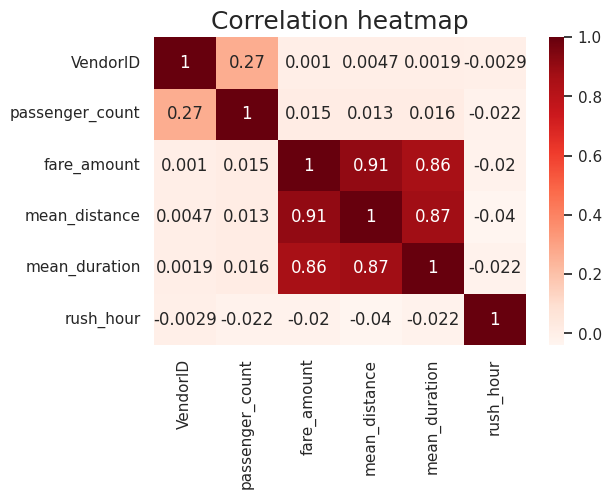

In [ ]:
# Create correlation heatmap

plt.figure(figsize=(6,4))
sns.heatmap(df2.corr(method='pearson'), annot=True, cmap='Reds')
plt.title('Correlation heatmap',
          fontsize=18)
plt.show()

mean_duration et mean_distance sont toutes deux fortement corrélées avec la variable cible fare_amount. Elles sont également corrélées entre elles, avec une corrélation de Pearson = 0,87.

Rappelez-vous que des variables prédictives fortement corrélées peuvent poser problème pour les modèles de régression linéaire si l’objectif est de tirer des inférences statistiques à partir du modèle. Cependant, ces variables corrélées peuvent toujours être utilisées pour créer un prédicteur précis si la précision de la prédiction est plus importante que l’analyse des relations entre variables.

Ce modèle a pour objectif de prédire fare_amount, qui sera ensuite utilisé comme variable prédictive dans d’autres modèles de machine learning. Par conséquent, essayez de modéliser avec les deux variables, même si elles sont corrélées.

#**PACE :CONSTRUCTION**

Après l’analyse et la création des variables ayant des relations étroites, il est temps de commencer à construire le modèle. Référez-vous aux questions de votre Document de Stratégie PACE pour réfléchir à l’étape Construct.

##Tâche 8a : Séparer les données en variable cible et en variables explicati

In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   VendorID         22699 non-null  int64  
 1   passenger_count  22699 non-null  int64  
 2   fare_amount      22699 non-null  float64
 3   mean_distance    22699 non-null  float64
 4   mean_duration    22699 non-null  float64
 5   rush_hour        22699 non-null  int64  
dtypes: float64(3), int64(3)
memory usage: 1.0 MB


Définissez vos variables X et y. X représente les variables explicatives (features) et y représente la variable cible (outcome).

In [ ]:
# Remove the target column from the features
X = df2.drop(columns=['fare_amount'])

# Set y variable
y = df2[['fare_amount']]

# Display first few rows
X.head()

,VendorID,passenger_count,mean_distance,mean_duration,rush_hour
0,2,6,3.521667,22.847222,0
1,1,1,3.108889,24.470370,0
2,1,1,0.881429,7.250000,1
3,2,1,3.700000,30.250000,0
4,2,1,4.435000,14.616667,0


##Tâche 8b : Prétraiter les données

Dummy encode categorical variables

In [ ]:
# Convert VendorID to string
X['VendorID'] = X['VendorID'].astype(str)

# Get dummies
X = pd.get_dummies(X, drop_first=True)
X.head()

,passenger_count,mean_distance,mean_duration,rush_hour,VendorID_2
0,6,3.521667,22.847222,0,True
1,1,3.108889,24.470370,0,False
2,1,0.881429,7.250000,1,False
3,1,3.700000,30.250000,0,True
4,1,4.435000,14.616667,0,True


Séparez les données en ensembles d’entraînement et de test.

Créez des ensembles d’entraînement et de test. L’ensemble de test doit contenir 20 % du total des échantillons. Définissez random_state=0.

In [ ]:
# Create training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

Standardisez les données. Utilisez StandardScaler(), fit() et transform() pour standardiser les variables X_train. Assignez le résultat à une variable appelée X_train_scaled.

In [ ]:
# Standardize the X variables
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
print('X_train scaled:', X_train_scaled)

X_train scaled: [[-0.50301524  0.8694684   0.17616665 -0.64893329  0.89286563]
 [-0.50301524 -0.60011281 -0.69829589  1.54099045  0.89286563]
 [ 0.27331093 -0.47829156 -0.57301906 -0.64893329 -1.11998936]
 ...
 [-0.50301524 -0.45121122 -0.6788917  -0.64893329 -1.11998936]
 [-0.50301524 -0.58944763 -0.85743597  1.54099045 -1.11998936]
 [ 1.82596329  0.83673851  1.13212101 -0.64893329  0.89286563]]


Instancions notre modèle et entraînez-le sur les données d’entraînement.

In [ ]:
# Fit your model to the training data
lr=LinearRegression()
lr.fit(X_train_scaled, y_train)

LinearRegression()

##Task 8c. Evaluate model

Entraînez les données. Évaluez les performances de votre modèle en calculant la somme des carrés des résidus, le coefficient de détermination (R²), l’erreur absolue moyenne, l’erreur quadratique moyenne et la racine carrée de l’erreur quadratique moyenne.

In [ ]:
# Evaluate the model performance on the training data
r_sq = lr.score(X_train_scaled, y_train)
print('Coefficient of determination:', r_sq)
y_pred_train = lr.predict(X_train_scaled)
print('R^2:', r2_score(y_train, y_pred_train))
print('MAE:', mean_absolute_error(y_train, y_pred_train))
print('MSE:', mean_squared_error(y_train, y_pred_train))
print('RMSE:',np.sqrt(mean_squared_error(y_train, y_pred_train)))

Coefficient of determination: 0.8398434585044773
R^2: 0.8398434585044773
MAE: 2.186666416775414
MSE: 17.88973296349268
RMSE: 4.229625629236313


Données de test :
Calculez les mêmes métriques sur les données de test. N’oubliez pas de standardiser les variables X_test en utilisant le scaler déjà ajusté sur les données d’entraînement. Ne réajustez pas le scaler sur les données de test, contentez-vous de les transformer. Appelez le résultat X_test_scaled.

In [ ]:
# Scale the X_test data
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Evaluate the model performance on the testing data
r_sq_test = lr.score(X_test_scaled, y_test)
print('Coefficient of determination:', r_sq_test)
y_pred_test = lr.predict(X_test_scaled)
print('R^2:', r2_score(y_test, y_pred_test))
print('MAE:', mean_absolute_error(y_test,y_pred_test))
print('MSE:', mean_squared_error(y_test, y_pred_test))
print('RMSE:',np.sqrt(mean_squared_error(y_test, y_pred_test)))

Coefficient of determination: 0.8682583641795454
R^2: 0.8682583641795454
MAE: 2.1336549840593864
MSE: 14.326454156998942
RMSE: 3.7850302716093225


Les performances du modèle sont élevées sur les ensembles d’entraînement et de test, ce qui suggère que le modèle présente peu de biais et n’est pas surajusté. En fait, les scores sur l’ensemble de test étaient même meilleurs que ceux sur l’ensemble d’entraînement.

Pour les données de test, un R² de 0,868 signifie que 86,8 % de la variance de la variable fare_amount est expliquée par le modèle.

L’erreur absolue moyenne (MAE) est informative ici, car, pour les besoins du modèle, une erreur de deux n’est pas plus de deux fois pire qu’une erreur de un.

#**PACE: EXÉCUTION**

Réfléchissons aux questions de votre Document de Stratégie PACE pour examiner l’étape Execute.

##Tâche 9a : Résultats

Utilisons la cellule de code ci-dessous pour obtenir les valeurs réelles, prédictions et résidus pour l’ensemble de test, et stockez-les sous forme de colonnes dans un dataframe résultats.

In [ ]:
 #Create a `results` dataframe
results = pd.DataFrame(data={'actual': y_test['fare_amount'],
                             'predicted': y_pred_test.ravel()})
results['residual'] = results['actual'] - results['predicted']
results.head()

,actual,predicted,residual
5818,14.0,12.356503,1.643497
18134,28.0,16.314595,11.685405
4655,5.5,6.726789,-1.226789
7378,15.5,16.227206,-0.727206
13914,9.5,10.536408,-1.036408


Tâche 9b : Visualiser les résultats du modèle

Créez un graphique en nuage de points (scatterplot) pour visualiser les valeurs réelles par rapport aux valeurs prédites.

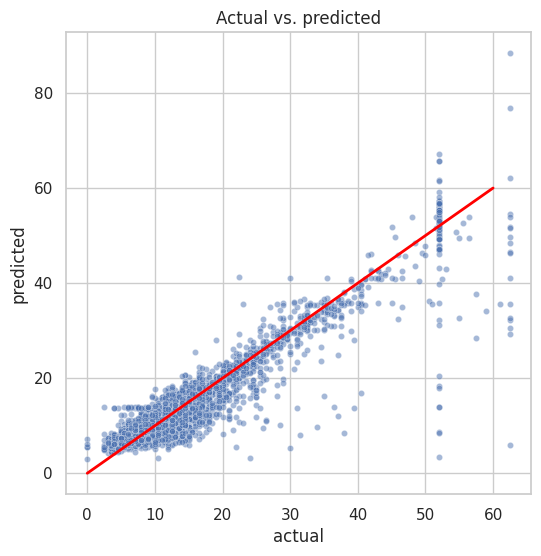

In [ ]:
# Create a scatterplot to visualize `predicted` over `actual`
fig, ax = plt.subplots(figsize=(6, 6))
sns.set(style='whitegrid')
sns.scatterplot(x='actual',
                y='predicted',
                data=results,
                s=20,
                alpha=0.5,
                ax=ax
)
# Draw an x=y line to show what the results would be if the model were perfect
plt.plot([0,60], [0,60], c='red', linewidth=2)
plt.title('Actual vs. predicted');

Visualize the distribution of the residuals using a histogram

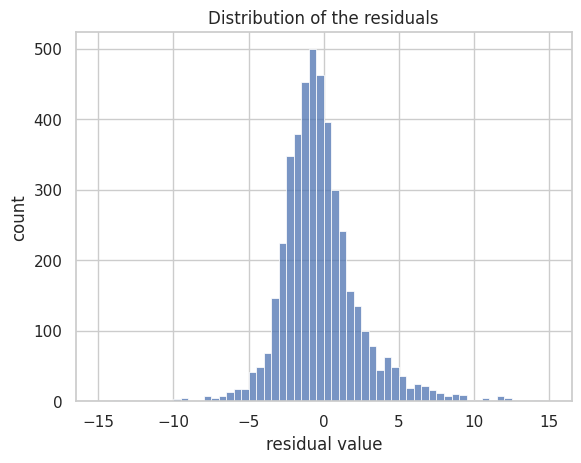

In [ ]:
# Visualize the distribution of the `residuals`
sns.histplot(results['residual'], bins=np.arange(-15,15.5,0.5))
plt.title('Distribution of the residuals')
plt.xlabel('residual value')
plt.ylabel('count');

In [ ]:
results['residual'].mean()

np.float64(-0.01544262152868054)

La distribution des résidus est approximativement normale et a une moyenne de -0,015. Les résidus représentent la variance de la variable cible qui n’est pas expliquée par le modèle. Une distribution normale autour de zéro est favorable, car elle montre que les erreurs du modèle sont uniformément réparties et non biaisées.



Créez un graphique en nuage de points des résidus en fonction des valeurs prédites.

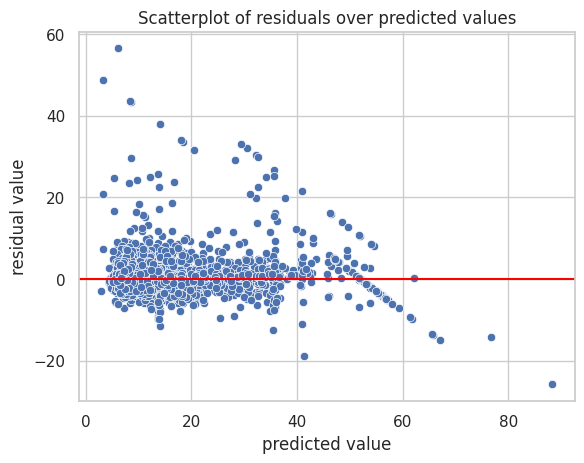

In [ ]:
# Create a scatterplot of `residuals` over `predicted`

sns.scatterplot(x='predicted', y='residual', data=results)
plt.axhline(0, c='red')
plt.title('Scatterplot of residuals over predicted values')
plt.xlabel('predicted value')
plt.ylabel('residual value')
plt.show()

Les résidus du modèle sont uniformément répartis au-dessus et en dessous de zéro, à l’exception des lignes inclinées allant du coin supérieur gauche au coin inférieur droit, qui correspondent au maximum imputé de 62,50 $ et au tarif forfaitaire de 52 $ pour les trajets vers l’aéroport JFK.

Tâche 9c : Coefficients

Utilisez l’attribut coef_ pour obtenir les coefficients du modèle. Les coefficients sont renvoyés dans l’ordre des variables explicatives utilisées pour entraîner le modèle.

In [ ]:
# Get model coefficients
coefficients = pd.DataFrame(lr.coef_, columns=X.columns)
coefficients


,passenger_count,mean_distance,mean_duration,rush_hour,VendorID_2
0,0.030825,7.133867,2.812115,0.110233,-0.054373


Les coefficients montrent que mean_distance était la variable ayant le poids le plus élevé dans la prédiction finale du modèle. Attention ! Une erreur fréquente est de dire que pour chaque mile parcouru, le tarif augmente en moyenne de 7,13 $. Cela est incorrect, car les données utilisées pour entraîner le modèle ont été standardisées avec StandardScaler(), donc les unités ne sont plus des miles.

L’interprétation correcte du coefficient est : en contrôlant les autres variables, pour chaque augmentation de +1 écart-type, le tarif augmente en moyenne de 7,13 $.

Notez également que comme certaines variables fortement corrélées n’ont pas été supprimées, l’intervalle de confiance de cette estimation est plus large.

Pour obtenir une interprétation en miles réels, il faut détrandardiser le coefficient :

In [ ]:
# 1. Calculate SD of `mean_distance` in X_train data
print(X_train['mean_distance'].std())

# 2. Divide the model coefficient by the standard deviation
print(7.133867 / X_train['mean_distance'].std())

3.574812975256415
1.9955916713344426


Nous pouvons maintenant donner une interprétation plus intuitive : pour chaque 3,57 miles parcourus, le tarif augmente en moyenne de 7,13 $. Ou, simplifié : pour chaque mile parcouru, le tarif augmente en moyenne de 2,00 $.

Tâche 9d : Conclusion

Principaux enseignements de ce notebook :

La régression linéaire multiple est un outil puissant pour estimer une variable dépendante continue à partir de plusieurs variables indépendantes.

L’analyse exploratoire des données est utile pour sélectionner à la fois des variables numériques et catégorielles pour la régression linéaire multiple.

L’ajustement d’un modèle de régression linéaire multiple peut nécessiter des essais et erreurs pour sélectionner les variables qui permettent un modèle précis tout en respectant les hypothèses du modèle (ou non, selon le cas d’usage).

Résultats présentables à partir de ce notebook :

La conformité aux hypothèses de la régression linéaire, notamment la distribution normale des résidus autour de zéro.

Les scores d’évaluation du modèle, tels que l’erreur absolue moyenne (MAE) et la racine de l’erreur quadratique moyenne (RMSE) obtenus sur les ensembles d’entraînement et de test

1. Predict on full dataset

In [ ]:
X_scaled = scaler.transform(X)
y_preds_full = lr.predict(X_scaled)

In [ ]:
# Create a new df containing just the RatecodeID col from the whole dataset
final_preds = df[['RatecodeID']].copy()

# Add a column containing all the predictions
final_preds['y_preds_full'] = y_preds_full

# Impute a prediction of 52 at all rows where RatecodeID == 2
final_preds.loc[final_preds['RatecodeID']==2, 'y_preds_full'] = 52

# Check that it worked
final_preds[final_preds['RatecodeID']==2].head()

,RatecodeID,y_preds_full
11,2,52.0
110,2,52.0
161,2,52.0
247,2,52.0
379,2,52.0


Check performance on full dataset

In [ ]:
final_preds = final_preds['y_preds_full']
print('R^2:', r2_score(y, final_preds))
print('MAE:', mean_absolute_error(y, final_preds))
print('MSE:', mean_squared_error(y, final_preds))
print('RMSE:',np.sqrt(mean_squared_error(y, final_preds)))

R^2: 0.8910853978683975
MAE: 1.992506252269974
MSE: 12.101575504689935
RMSE: 3.4787318816905013


Save final predictions with mean_duration and mean_distance columns

In [ ]:
# Combine means columns with predictions column
nyc_preds_means = df[['mean_duration', 'mean_distance']].copy()
nyc_preds_means['predicted_fare'] = final_preds

nyc_preds_means.head()

,mean_duration,mean_distance,predicted_fare
0,22.847222,3.521667,16.434245
1,24.470370,3.108889,16.052218
2,7.250000,0.881429,7.053706
3,30.250000,3.700000,18.731650
4,14.616667,4.435000,15.845642



Lorsque les colonnes mean_distance et mean_duration ont été calculées, les moyennes ont été calculées à partir de l’ensemble complet des données. Ces mêmes colonnes ont ensuite été utilisées pour entraîner un modèle servant à prédire sur un ensemble de test. Or, un ensemble de test est censé représenter des données entièrement nouvelles que le modèle n’a jamais vues. Dans ce cas, certaines de ses variables prédictives ont été dérivées à partir de données qui se trouvaient dans l’ensemble de test.

Ceci est connu sous le nom de fuite de données (data leakage). Une fuite de données survient lorsque des informations provenant de l’ensemble d’entraînement contaminent l’ensemble de test. Si votre modèle présente des scores anormalement élevés, il y a de fortes chances qu’une fuite de données ait eu lieu.

Pour éviter la fuite de données dans ce processus de modélisation, il serait préférable de calculer les moyennes uniquement sur l’ensemble d’entraînement, puis de les copier dans l’ensemble de test. Cela empêcherait les valeurs de l’ensemble de test d’être incluses dans le calcul des moyennes. Cependant, cela peut poser problème si certaines combinaisons de lieux de prise en charge et de dépose apparaissent uniquement dans l’ensemble de test, ce qui créerait des NaN dans le test et nécessiterait des étapes supplémentaires pour les traiter.

Dans ce cas, la fuite de données a amélioré le score R² d’environ 0,03.

Imputer le tarif pour RatecodeID 2 après l’entraînement du modèle, puis calculer les métriques de performance sur ces données imputées, n’est pas une bonne pratique. Il serait préférable de séparer les trajets qui n’ont pas RatecodeID = 2, d’entraîner le modèle sur ces données, puis d’ajouter ensuite les trajets avec RatecodeID = 2 et leurs tarifs imputés. Cela éviterait d’entraîner le modèle sur des données pour lesquelles un modèle n’est pas nécessaire et améliorerait probablement le modèle final. Cependant, les étapes ont été combinées ici pour simplifier l’explication.

Les modèles qui prédissent des valeurs destinées à être utilisées dans un autre modèle en aval sont courants dans les flux de travail de data science. Lors du déploiement, le nettoyage des données, les imputations, les séparations, les prédictions, etc. sont effectués via des pipelines de modélisation. Ici, Pandas a été utilisé pour expliquer et granulariser certains concepts, mais ce processus serait simplifié par des ingénieurs en machine learning. Les idées sont les mêmes, mais l’implémentation diffère. Une fois le flux de travail validé, tout le processus peut être automatisé, souvent sans avoir besoin de Pandas ni de vérifier les sorties à chaque étape. L’ensemble du processus pourrait alors être réduit à une seule page de code.